In [1]:
import matplotlib.pyplot as plt
import importlib
import numpy as np
import pickle
from pathlib import Path

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "models").exists():
    PROJECT_ROOT = Path(__file__).resolve().parents[2] if '__file__' in dir() else Path.cwd()
    while not (PROJECT_ROOT / "models").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
        PROJECT_ROOT = PROJECT_ROOT.parent

SCRATCH_MODEL_DIR = PROJECT_ROOT / "models" / "regression" / "scratch"
LIB_MODEL_DIR = PROJECT_ROOT / "models" / "regression" / "lib"

def load_regression_model(model_name, source="scratch"):
    base = SCRATCH_MODEL_DIR if source == "scratch" else LIB_MODEL_DIR
    path = base / model_name / "model.pkl"
    if path.exists():
        with open(path, "rb") as f:
            pkg = pickle.load(f)
        print(f"Loaded {source}/{model_name} from {path}")
        return pkg
    else:
        print(f"No saved model at {path} — run training cell")
        return None

In [3]:
import src.modeling.regression.scratch.linear_regression.train as scratch_linear_regression_train
_pkg = load_regression_model("linear_regression", "scratch")
if _pkg and "metrics" in _pkg:
    scratch_linear_regression_metrics = _pkg["metrics"]
else:
    importlib.reload(scratch_linear_regression_train)
    scratch_linear_regression_metrics = scratch_linear_regression_train.train()

No saved model at e:\GithubFile\ML-PROJECT\models\regression\scratch\linear_regression\model.pkl — run training cell


In [5]:
import src.modeling.regression.scratch.poly_regression.train as scratch_poly_regression_train
_pkg = load_regression_model("poly_regression", "scratch")
if _pkg and "metrics" in _pkg:
    scratch_poly_regression_metrics = _pkg["metrics"]
else:
    importlib.reload(scratch_poly_regression_train)
    scratch_poly_regression_metrics = scratch_poly_regression_train.train()

No saved model at e:\GithubFile\ML-PROJECT\models\regression\scratch\poly_regression\model.pkl — run training cell


In [6]:
import src.modeling.regression.scratch.multiple_regression.train as scratch_multiple_regression_train
_pkg = load_regression_model("multiple_regression", "scratch")
if _pkg and "metrics" in _pkg:
    scratch_multiple_regression_metrics = _pkg["metrics"]
else:
    importlib.reload(scratch_multiple_regression_train)
    scratch_multiple_regression_metrics = scratch_multiple_regression_train.train()

No saved model at e:\GithubFile\ML-PROJECT\models\regression\scratch\multiple_regression\model.pkl — run training cell


In [7]:
import src.modeling.regression.scratch.gradient_boosting.train as gradient_boosting_regression_train
_pkg = load_regression_model("gradient_boosting", "scratch")
if _pkg and "metrics" in _pkg:
    gradient_boosting_regression_metrics = _pkg["metrics"]
else:
    importlib.reload(gradient_boosting_regression_train)
    gradient_boosting_regression_metrics = gradient_boosting_regression_train.train()

No saved model at e:\GithubFile\ML-PROJECT\models\regression\scratch\gradient_boosting\model.pkl — run training cell


In [8]:
import src.modeling.regression.lib.linear_regression.train as sklearn_linear_regression_train
_pkg = load_regression_model("linear_regression", "lib")
if _pkg and "metrics" in _pkg:
    sklearn_linear_regression_metrics = _pkg["metrics"]
else:
    importlib.reload(sklearn_linear_regression_train)
    sklearn_linear_regression_metrics = sklearn_linear_regression_train.train()

No saved model at e:\GithubFile\ML-PROJECT\models\regression\lib\linear_regression\model.pkl — run training cell


In [9]:
import src.modeling.regression.lib.poly_regression.train as sklearn_poly_regression_train
_pkg = load_regression_model("poly_regression", "lib")
if _pkg and "metrics" in _pkg:
    sklearn_poly_regression_metrics = _pkg["metrics"]
else:
    importlib.reload(sklearn_poly_regression_train)
    sklearn_poly_regression_metrics = sklearn_poly_regression_train.train()

No saved model at e:\GithubFile\ML-PROJECT\models\regression\lib\poly_regression\model.pkl — run training cell


In [10]:
import src.modeling.regression.lib.multiple_regression.train as sklearn_multiple_regression_train
_pkg = load_regression_model("multiple_regression", "lib")
if _pkg and "metrics" in _pkg:
    sklearn_multiple_regression_metrics = _pkg["metrics"]
else:
    importlib.reload(sklearn_multiple_regression_train)
    sklearn_multiple_regression_metrics = sklearn_multiple_regression_train.train()

No saved model at e:\GithubFile\ML-PROJECT\models\regression\lib\multiple_regression\model.pkl — run training cell


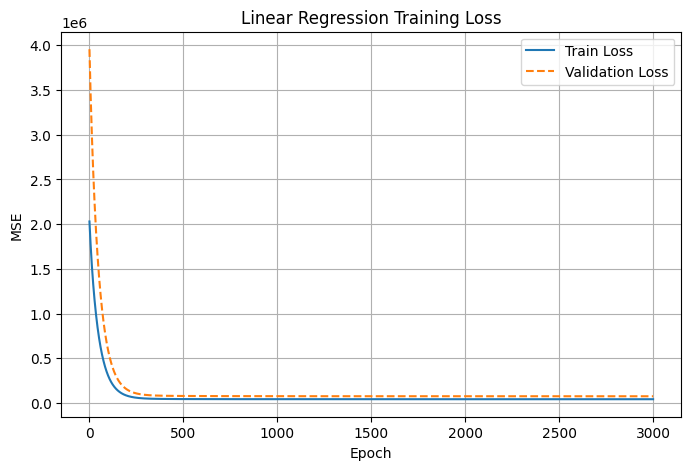

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(scratch_linear_regression_metrics["Loss History"], label="Train Loss")
plt.plot(scratch_linear_regression_metrics["Val History"], label="Validation Loss", linestyle="--")

plt.title("Linear Regression Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)

plt.show()

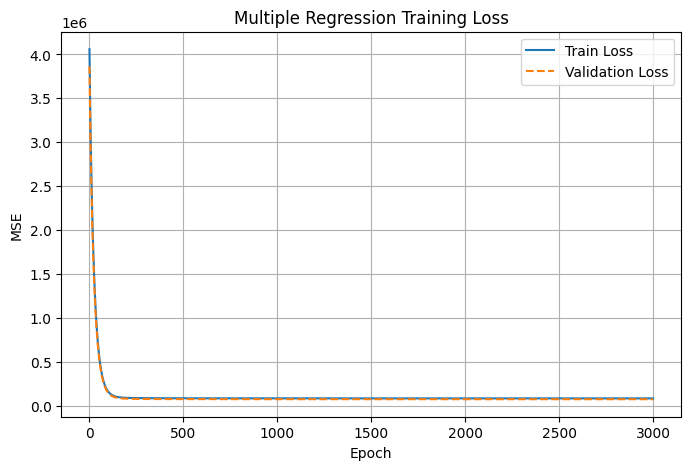

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(scratch_multiple_regression_metrics["Loss History"], label="Train Loss")
plt.plot(scratch_multiple_regression_metrics["Val History"], label="Validation Loss", linestyle="--")

plt.title("Multiple Regression Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)

plt.show()

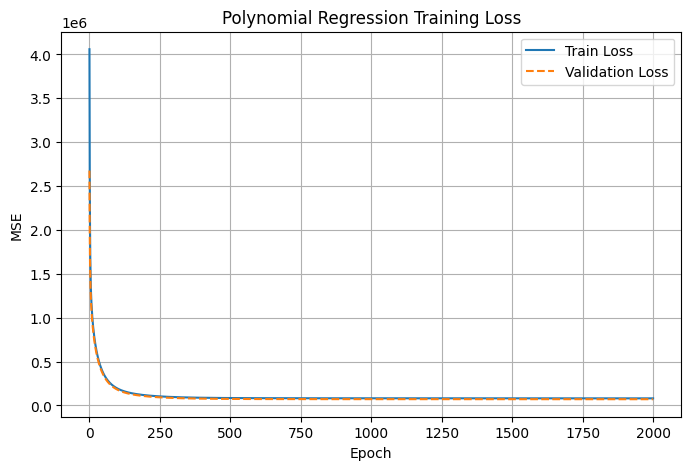

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(scratch_poly_regression_metrics["Loss History"], label="Train Loss")
plt.plot(scratch_poly_regression_metrics["Val History"], label="Validation Loss", linestyle="--")

plt.title("Polynomial Regression Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)

plt.show()

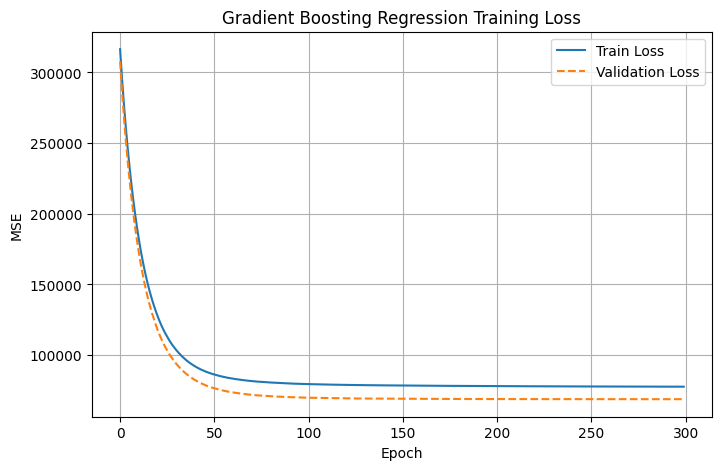

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(gradient_boosting_regression_metrics["Loss History"], label="Train Loss")
plt.plot(gradient_boosting_regression_metrics["Val History"], label="Validation Loss", linestyle="--")

plt.title("Gradient Boosting Regression Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)

plt.show()

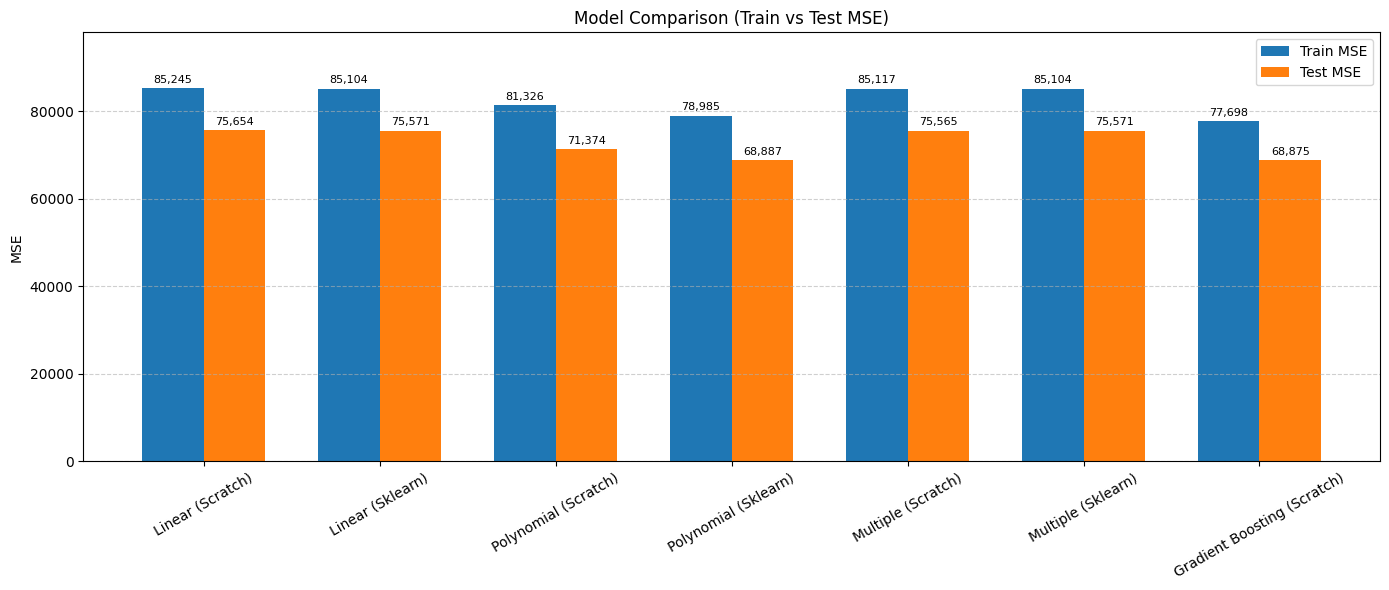

In [15]:
models = [
    "Linear (Scratch)",
    "Linear (Sklearn)",
    "Polynomial (Scratch)",
    "Polynomial (Sklearn)",
    "Multiple (Scratch)",
    "Multiple (Sklearn)",
    "Gradient Boosting (Scratch)"
]

train_mse = [
    scratch_linear_regression_metrics["Train MSE"],
    sklearn_linear_regression_metrics["Train MSE"],
    scratch_poly_regression_metrics["Train MSE"],
    sklearn_poly_regression_metrics["Train MSE"],
    scratch_multiple_regression_metrics["Train MSE"],
    sklearn_multiple_regression_metrics["Train MSE"],
    gradient_boosting_regression_metrics["Train MSE"],
]

test_mse = [
    scratch_linear_regression_metrics["Test MSE"],
    sklearn_linear_regression_metrics["Test MSE"],
    scratch_poly_regression_metrics["Test MSE"],
    sklearn_poly_regression_metrics["Test MSE"],
    scratch_multiple_regression_metrics["Test MSE"],
    sklearn_multiple_regression_metrics["Test MSE"],
    gradient_boosting_regression_metrics["Test MSE"],
]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(14, 6))

bars_train = plt.bar(x - width/2, train_mse, width, label="Train MSE")
bars_test = plt.bar(x + width/2, test_mse, width, label="Test MSE")

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height * 1.01,  
            f"{height:,.0f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

add_labels(bars_train)
add_labels(bars_test)

plt.xticks(x, models, rotation=30)
plt.ylabel("MSE")
plt.title("Model Comparison (Train vs Test MSE)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.ylim(0, max(max(train_mse), max(test_mse)) * 1.15)

plt.tight_layout()
plt.show()

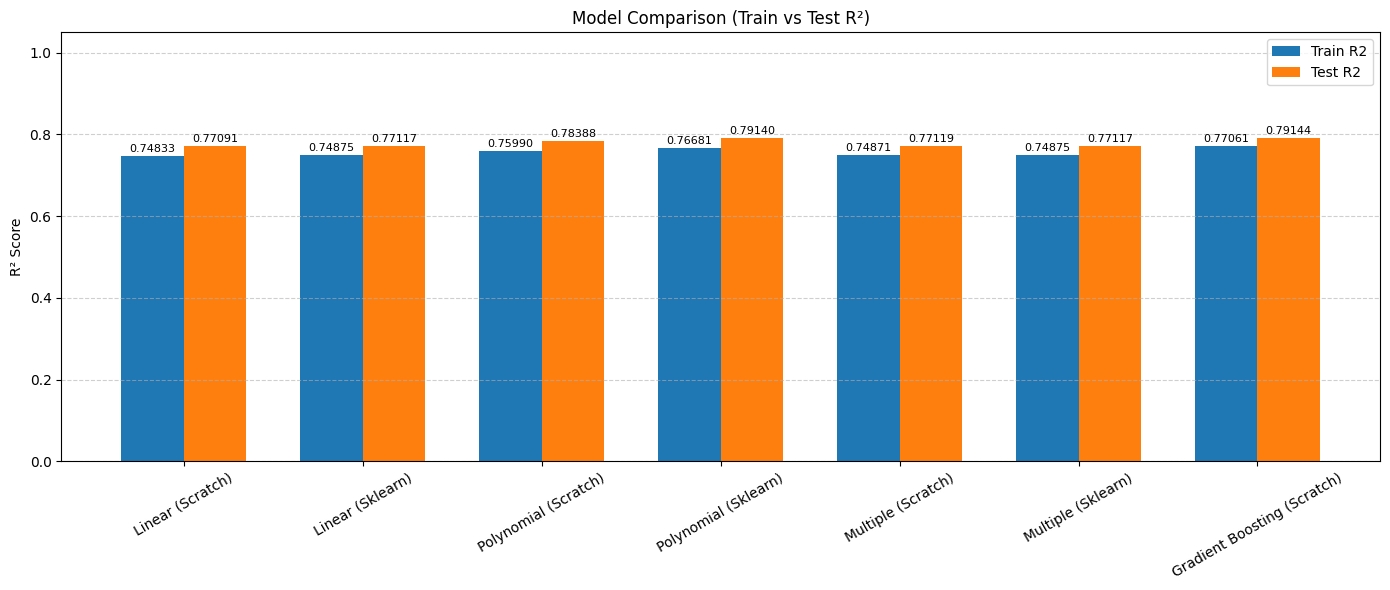

In [16]:
models = [
    "Linear (Scratch)",
    "Linear (Sklearn)",
    "Polynomial (Scratch)",
    "Polynomial (Sklearn)",
    "Multiple (Scratch)",
    "Multiple (Sklearn)",
    "Gradient Boosting (Scratch)"
]

train_r2 = [
    scratch_linear_regression_metrics["Train R2"],
    sklearn_linear_regression_metrics["Train R2"],
    scratch_poly_regression_metrics["Train R2"],
    sklearn_poly_regression_metrics["Train R2"],
    scratch_multiple_regression_metrics["Train R2"],
    sklearn_multiple_regression_metrics["Train R2"],
    gradient_boosting_regression_metrics["Train R2"],
]

test_r2 = [
    scratch_linear_regression_metrics["Test R2"],
    sklearn_linear_regression_metrics["Test R2"],
    scratch_poly_regression_metrics["Test R2"],
    sklearn_poly_regression_metrics["Test R2"],
    scratch_multiple_regression_metrics["Test R2"],
    sklearn_multiple_regression_metrics["Test R2"],
    gradient_boosting_regression_metrics["Test R2"],
]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(14, 6))

bars_train = plt.bar(x - width/2, train_r2, width, label="Train R2")
bars_test = plt.bar(x + width/2, test_r2, width, label="Test R2")

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.005,
            f"{height:.5f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

add_labels(bars_train)
add_labels(bars_test)

plt.xticks(x, models, rotation=30)
plt.ylabel("R² Score")
plt.title("Model Comparison (Train vs Test R²)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()